# introduction to quantum audio
Article : [Quantum Representations of Sound: from
mechanical waves to quantum circuits](https://arxiv.org/pdf/2301.01595)


# Quantum State Modulation: QSM

$$ |A_\rangle = \frac{1}{\sqrt{N}}\sum_{i=0}^{N-1} |S_i\rangle\otimes|i\rangle$$

In the litterature, this notation has two forms, such as $QSM$ where the amplitudes are represented with unsigned int, and the $QRDA$ (Quantum Representation for Digital Audio) or $FRQA$ (Flexible Representation of Quantum Audio), where the amplitudes values are represented with signed int. The two methods are equivalent. 


The time register use $n$ qubits, and the amplitudes register use $q$ qubits. 

## Preparation

Value-Setting Operation: For each time state,
- Step 1: Have a binary form of the time state’s label stored in a classical variable.
- Step 2: Have the binary form of the quantized audio sample at the same index
- Step 3: If a bit in a given position of the time variable is zero, apply an X gate at the
respective qubit. Verify all bits.
- Step 4: If a bit in a given position of the audio sample is 1, apply a multi-controlled
CNOT gate. Verify all bits.
- Step 5: Repeat the third instruction to reset the control condition.

In [1]:
# importation of the modules
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.circuit.library import XGate
from qiskit import transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [2]:
# Functions 
def getFullScaleMeasured(statistics, Nqubits):
    """
    fill the string measured with the null values measured
    Input : 
        - statistics(dict)
        - Nqubits(int)
    Output:
        - full_statistics(dict): statistics with the null values
    """
    full_statistics = {}
    for i in range(2**Nqubits):
        # Converts the integer i to binary and adds leading zeros (padding)
        bitstring = format(i, f'0{Nqubits}b')
        
        # If the flag is set, we take its value; otherwise, we set it to 0
        full_statistics[bitstring] = statistics.get(bitstring, 0)
    return full_statistics

# generation of the binary list depending of the number of qubits
def generate_binary_list_from_nqubits(n_qubits):
    """
    Generates binary strings in ascending numerical order.
    Example for 2 qubits: [‘00’, ‘01’, ‘10’, ‘11’]
    Input: 
        - n_qubits(Int) : number of qubits
    Output:
        - list of 2**n_qubits binary ascendant
    """
    return [format(i, f'0{n_qubits}b') for i in range(2**n_qubits)]

def quantize2normalize(quantizeSignal: np.array, Resolution: int):
    """
    Convert the quantized signal(amplitudes 0 and 2**Resolution) 
                to normalized signal(amplitudes between -1 and 1)
    """
    normalizeSignal =  2*(quantizeSignal/(2**Resolution-1))-1
    return normalizeSignal

def normalize2quantize(signal: np.array, Resolution: int):
    """
    Convert the normalized signal(amplitudes between -1 and 1)
                to quantized signal(amplitudes between 0 and 2**Resolution).
    """
    quantizeSignal = np.round((signal+1)/2*(2**Resolution-1))
    return quantizeSignal


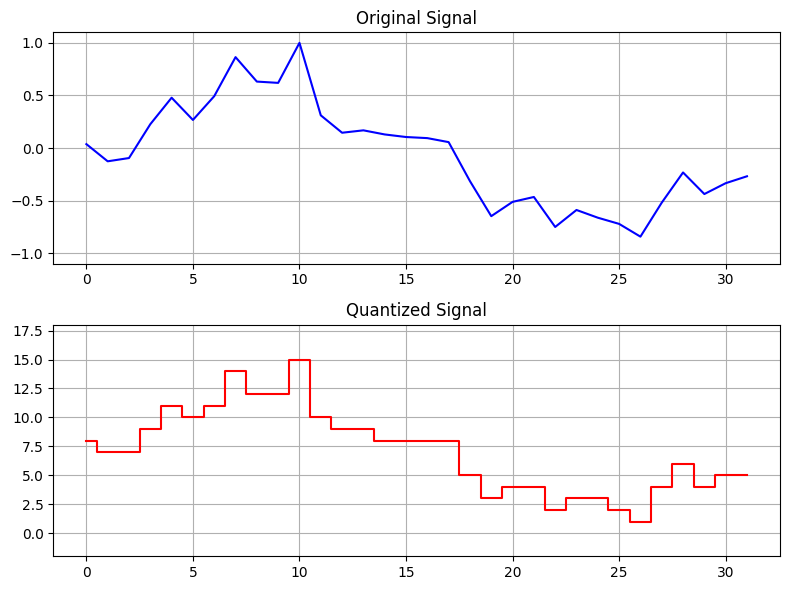

In [3]:
# Creation of an audio signal 

# Resolution
AmpQubits = 4   # better resolution with an high number of amplitude qubits 
TimeQubits = 5

# time vector
temp = np.arange(0,2**TimeQubits, 1)/2**TimeQubits

# Creation of a signal 
amplitudes = np.sin(2*np.pi*temp)+0.3*np.random.randn(2**TimeQubits) # sinus wave + random data
amplitudes/=np.max(np.abs(amplitudes)) # normalization

# Quantization of the signal 
quantizeSignal = normalize2quantize(amplitudes, AmpQubits)


# Plot the signal and the quantized signal 
fig, axs = plt.subplots(2, 1, figsize=(8, 6))
axs[0].plot(amplitudes, color='blue')
axs[0].set_title("Original Signal")
axs[0].set_ylim([-1.1, 1.1])
axs[0].grid(True)

axs[1].plot(quantizeSignal, color='red', drawstyle='steps-mid')
axs[1].set_title("Quantized Signal")
axs[1].grid(True)
axs[1].set_ylim([-2, 2**AmpQubits+2])
plt.tight_layout()
plt.show()

In [4]:
# convert samples to binary value
signal_binary = [f"{x:0{AmpQubits}b}" for x in quantizeSignal.astype(int)]
print(f"Binary representation of the signal : {signal_binary}")

# time binary values 
TimeBin = generate_binary_list_from_nqubits(TimeQubits)
print(f"Binary representation of the time : {TimeBin}")

Binary representation of the signal : ['1000', '0111', '0111', '1001', '1011', '1010', '1011', '1110', '1100', '1100', '1111', '1010', '1001', '1001', '1000', '1000', '1000', '1000', '0101', '0011', '0100', '0100', '0010', '0011', '0011', '0010', '0001', '0100', '0110', '0100', '0101', '0101']
Binary representation of the time : ['00000', '00001', '00010', '00011', '00100', '00101', '00110', '00111', '01000', '01001', '01010', '01011', '01100', '01101', '01110', '01111', '10000', '10001', '10010', '10011', '10100', '10101', '10110', '10111', '11000', '11001', '11010', '11011', '11100', '11101', '11110', '11111']


### Preparation

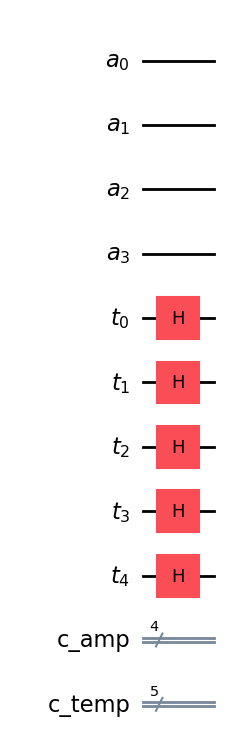

In [5]:
# Quantum register
q_amp = QuantumRegister(AmpQubits, "a")
q_temp = QuantumRegister(TimeQubits, "t")

#classical register
c_amp = ClassicalRegister(AmpQubits, "c_amp")
c_temp = ClassicalRegister(TimeQubits, "c_temp")

# creation of the circuit with hadamard gates on time qubits
circuit = QuantumCircuit(q_amp, q_temp, c_amp, c_temp)

circuit.h(q_temp)
display(circuit.draw(output="mpl"))

In [6]:
# Run over the time value
for indexTimeBin, timebinary in enumerate(TimeBin):
    # find null index in the time binary string
    indices_zeros_time = [i+AmpQubits for i, bit in enumerate(reversed(timebinary)) if bit == '0']

    # find index in the amp binary string which value is equal to 1
    indices_ones_Amp = [i for i, bit in enumerate(reversed(signal_binary[indexTimeBin])) if bit == '1']
        
    # Add Controled-X gates depending if the binary value of the samples is equal to 1.
    if indices_ones_Amp:
        if indices_zeros_time:
            circuit.x(indices_zeros_time)
            for ff in indices_ones_Amp:
                # apply X gates
        
                # apply Ry controled gate
                cx_gate = XGate().control(TimeQubits) #Controled X gates
                #circuit.append(cx_gate, list(treg)+list(Ampreg[ff]))
                circuit.append(cx_gate, list(q_temp) + [q_amp[ff]])

                # apply X gates
            circuit.x(indices_zeros_time)
            circuit.barrier()
        else:
            # If any null value is found in time binary value, apply only an Controlled X gate on amp value equal to 1.
            for ff in indices_ones_Amp:
                cx_gate = XGate().control(TimeQubits) #/!\ the angle to apply is twice in qiskit
                circuit.append(cx_gate, list(q_temp)+ [q_amp[ff]])
                circuit.barrier()

# measure
circuit.measure(q_amp, c_amp)
circuit.measure(q_temp, c_temp)


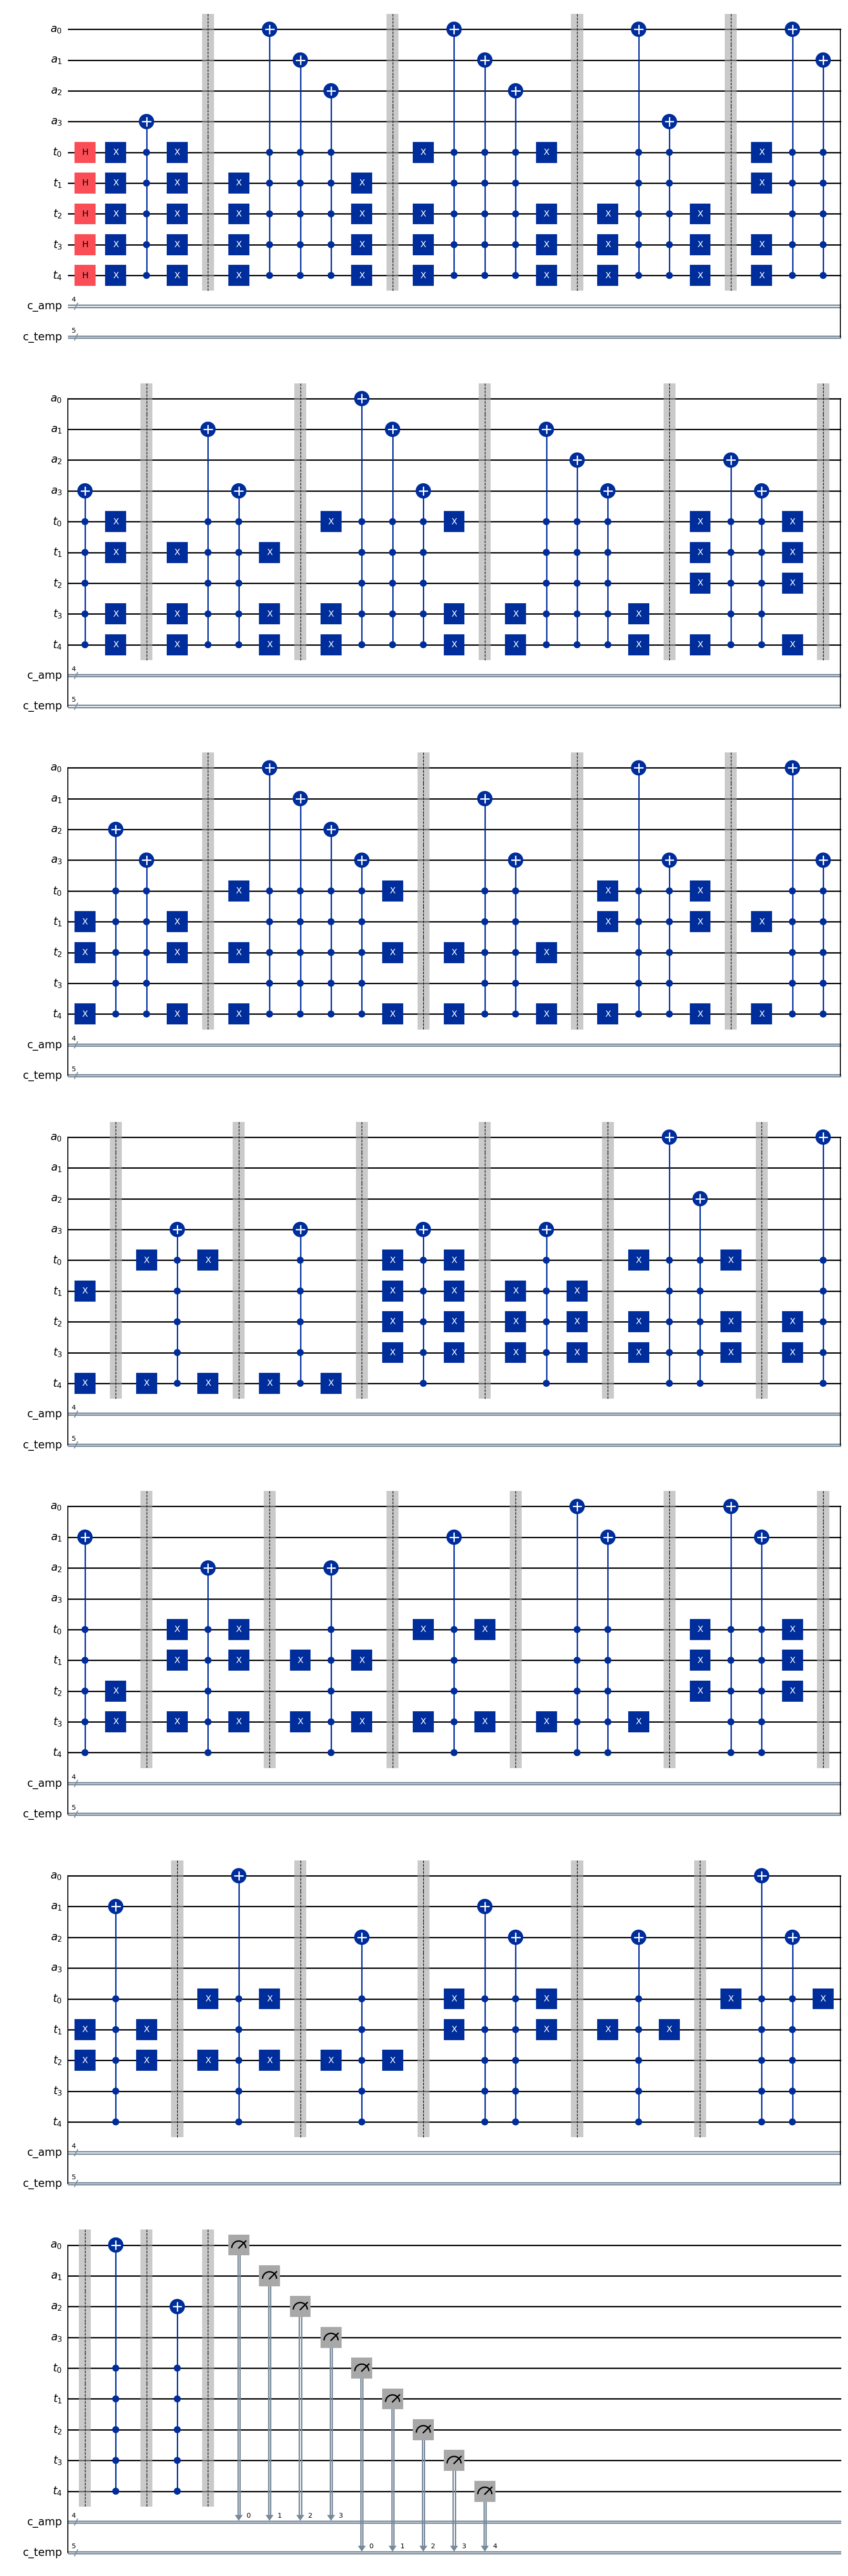

In [7]:
display(circuit.draw(output="mpl"))

(CVXPY) Apr 07 01:33:12 AM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.14.6206). Expected < 9.12.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Apr 07 01:33:12 AM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.14.6206). Expected < 9.12.0. Please open a feature request on cvxpy to enable support for this version.')


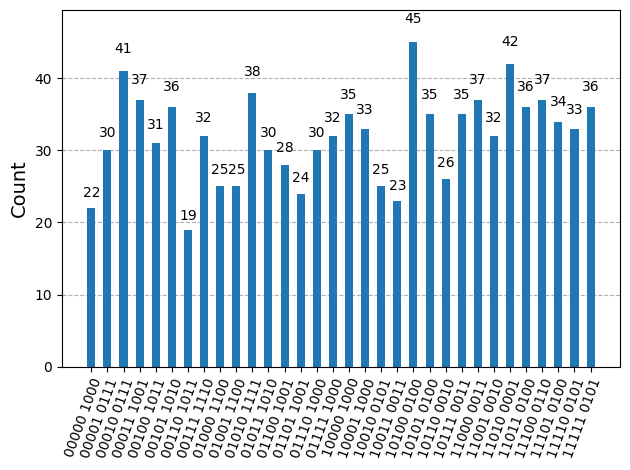

In [8]:
# run on backend then plot the histogramm
simulator = AerSimulator()
stats = simulator.run(circuit.decompose(), shots = 1024).result()
statistics = stats.get_counts()
display(plot_histogram(statistics))

In [9]:
# Run the circuit
simulator = AerSimulator()
compiled_circuit = transpile(circuit, simulator)
result = simulator.run(compiled_circuit, shots=1024).result()
counts = result.get_counts()

# rearranged data by 
data_points = []
for full_bin, count in counts.items():
    # Separation of the amplitudes and time register
    time_bin, amp_bin = full_bin.split(' ')
    
    # Conversion binary -> int
    time_int = int(time_bin, 2)
    amp_int = int(amp_bin, 2)
    
    data_points.append({
        'time': time_int,
        'amp': amp_int,
        'probability': count / sum(counts.values())
    })

# Sort by ascending time
data_points.sort(key=lambda x: x['time'])

## Retrieval the signal 
The way to recovert the signal is according the time measured values, the data are rearranged to get the amplitudes value. Then the signal is reconstructed. 
To het a better resolution of the signal in amplitude, the system required more qubit $a$.

In [10]:
# Retrieval of the signal
signal_reconstruit = np.zeros(2**TimeQubits)
for point in data_points:
    # The measured amplitude is plotted at the corresponding time point
    signal_reconstruit[point['time']] = point['amp']

print("Retrieval of the signal :")
print(signal_reconstruit)

Retrieval of the signal :
[ 8.  7.  7.  9. 11. 10. 11. 14. 12. 12. 15. 10.  9.  9.  8.  8.  8.  8.
  5.  3.  4.  4.  2.  3.  3.  2.  1.  4.  6.  4.  5.  5.]


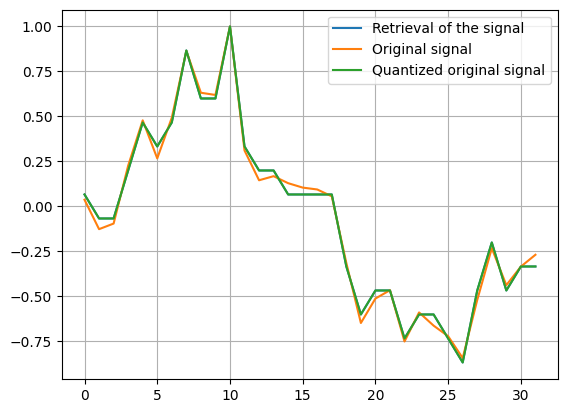

In [11]:
# Plot the retrieval signal with the original and Quantized signal
sigRec = quantize2normalize(signal_reconstruit, AmpQubits)
sigQuantize = quantize2normalize(quantizeSignal, AmpQubits)


plt.plot(sigRec, label="Retrieval of the signal")
plt.plot(amplitudes, label="Original signal")
plt.plot(sigQuantize, label="Quantized original signal")
plt.legend()
plt.grid()